In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../../../data-engineering/etl-pipeline-project/data/processed_countries.csv')

df.head()

,country,capital,region,subregion,population,area_km2,population_density
0,India,New Delhi,Asia,Southern Asia,1417492000,3287263.0,431.21
1,China,Beijing,Asia,Eastern Asia,1408280000,9706961.0,145.08
2,United States,"Washington, D.C.",Americas,North America,340110988,9525067.0,35.71
3,Indonesia,Jakarta,Asia,South-Eastern Asia,284438782,1904569.0,149.35
4,Pakistan,Islamabad,Asia,Southern Asia,241499431,796095.0,303.36


In [3]:
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")
print(f"\nColumn names: {list(df.columns)}")
print(f"\nData types:")
print(df.dtypes)
print(f"\nNull values:")
print(df.isnull().sum())

Rows: 195
Columns: 7

Column names: ['country', 'capital', 'region', 'subregion', 'population', 'area_km2', 'population_density']

Data types:
country                object
capital                object
region                 object
subregion              object
population              int64
area_km2              float64
population_density    float64
dtype: object

Null values:
country               0
capital               0
region                0
subregion             0
population            0
area_km2              0
population_density    0
dtype: int64


In [5]:
df.describe()

,population,area_km2,population_density
count,1.950000e+02,1.950000e+02,195.000000
mean,4.089452e+07,6.849642e+05,311.541897
std,1.483032e+08,1.911543e+06,1503.971688
min,8.820000e+02,4.900000e-01,2.270000
25%,1.801960e+06,2.308300e+04,34.000000
50%,9.109280e+06,1.184840e+05,87.940000
75%,3.172316e+07,5.205440e+05,199.930000
max,1.417492e+09,1.709825e+07,19021.290000


In [7]:
# Find the most and least dense countries
print("Top 5 most dense countries:")
print(df.nlargest(5, 'population_density')[['country', 'population_density', 'region']])

print("\nTop 5 least dense countries:")
print(df.nsmallest(5, 'population_density')[['country', 'population_density', 'region']])

Top 5 most dense countries:
          country  population_density  region
189        Monaco            19021.29  Europe
110     Singapore             8605.92    Asia
148       Bahrain             2084.52    Asia
165         Malta             1817.25  Europe
194  Vatican City             1800.00  Europe

Top 5 least dense countries:
       country  population_density    region
129   Mongolia                2.27      Asia
53   Australia                3.58   Oceania
160     Guyana                3.60  Americas
134    Namibia                3.66    Africa
164   Suriname                3.76  Americas


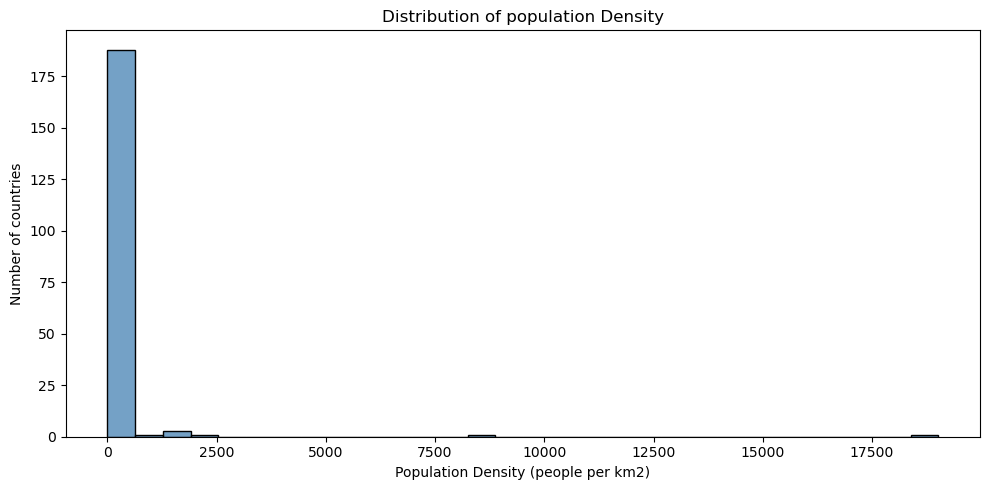

In [9]:
plt.figure(figsize=(10, 5))
sns.histplot(df['population_density'], bins=30, color='steelblue')
plt.title('Distribution of population Density')
plt.xlabel('Population Density (people per km2)')
plt.ylabel('Number of countries')
plt.tight_layout()
plt.show()

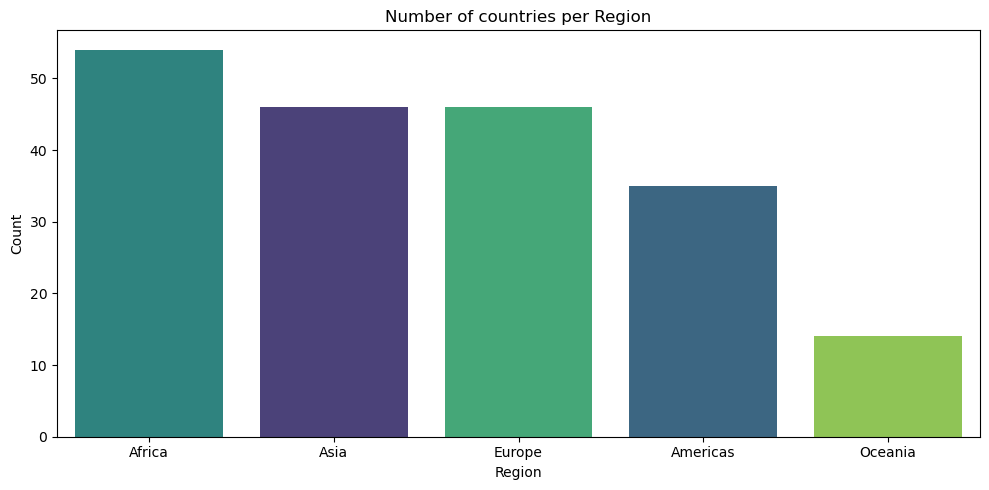

In [17]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='region',
              order=df['region'].value_counts().index,
              hue = 'region',
              legend=False,
              palette='viridis')
plt.title('Number of countries per Region')
plt.xlabel('Region')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

In [23]:
region_density = df.groupby('region')['population_density'].mean().sort_values(ascending=False)
print(region_density)

region
Europe      612.678043
Asia        441.535435
Oceania     135.180714
Americas    128.564571
Africa      108.602963
Name: population_density, dtype: float64


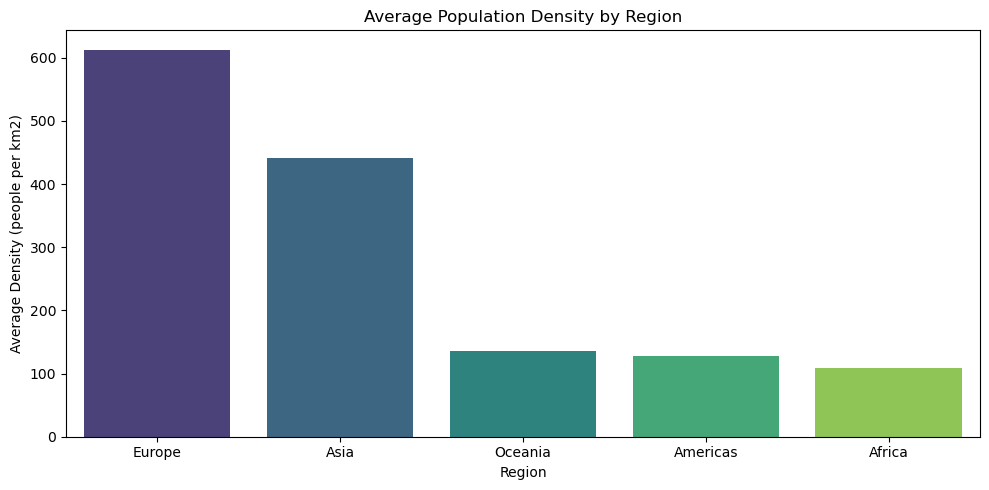

In [35]:
plt.figure(figsize=(10, 5))
sns.barplot(x=region_density.index,
            y=region_density.values,
            hue=region_density.index,
            legend=False,
            palette='viridis')
plt.title('Average Population Density by Region')
plt.xlabel('Region')
plt.ylabel('Average Density (people per km2)')
plt.tight_layout()
plt.show()

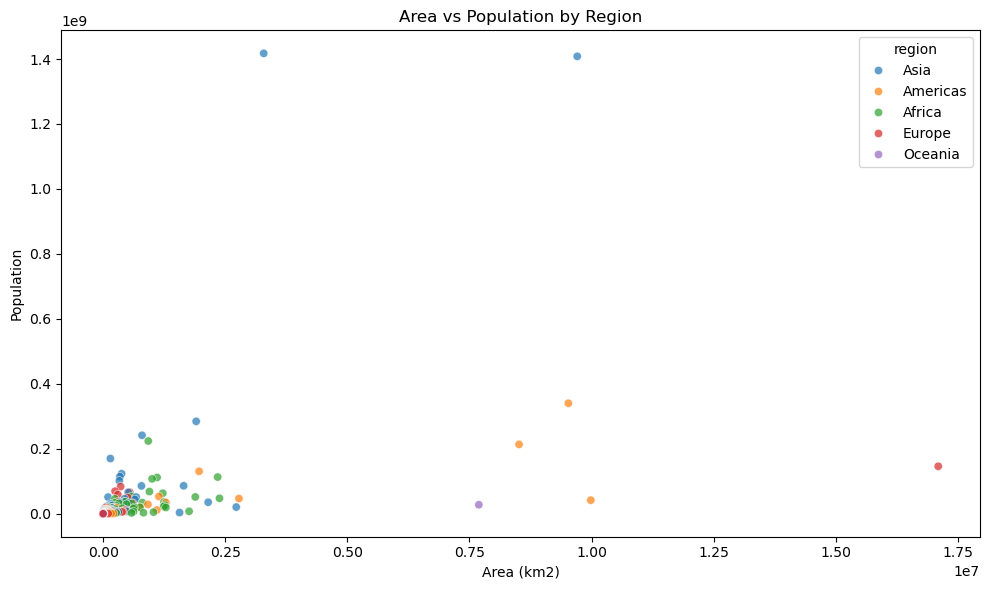

In [41]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df,
               x='area_km2',
               y='population',
               hue='region',
               alpha=0.7)
plt.title('Area vs Population by Region')
plt.xlabel('Area (km2)')
plt.ylabel('Population')
plt.tight_layout()
plt.show()

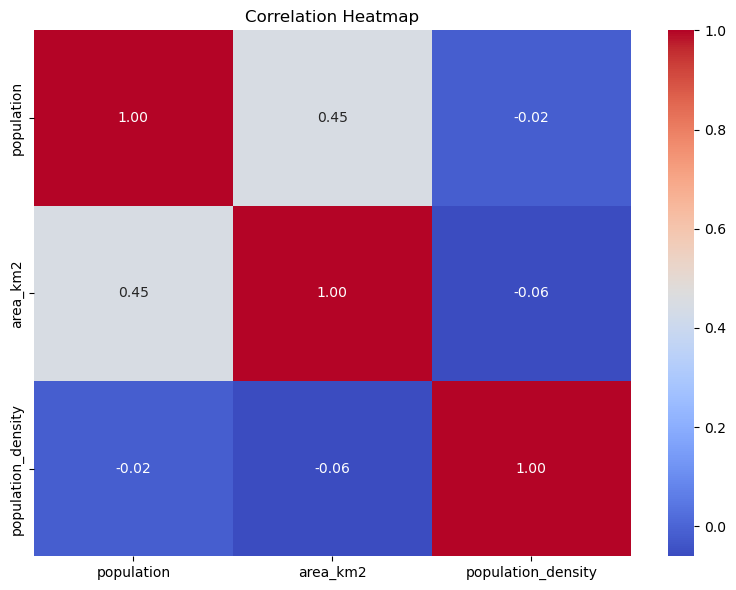

In [43]:
plt.figure(figsize=(8,6))
sns.heatmap(df[['population', 'area_km2', 'population_density']].corr(),
            annot=True,
            cmap='coolwarm',
            fmt='.2f')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

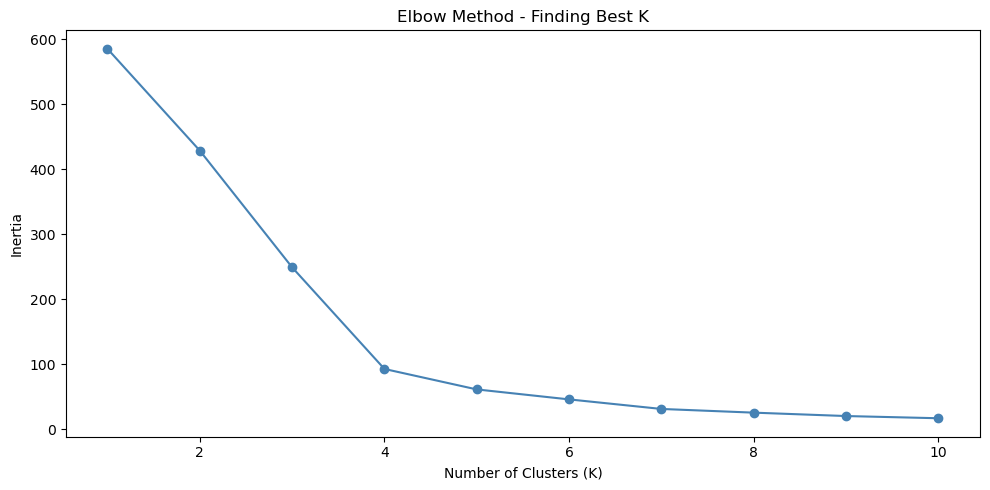

In [53]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import warnings
warnings.filterwarnings('ignore')

features = df[['population','area_km2','population_density']]

scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

inertia = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_features)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(10, 5))
plt.plot(k_range, inertia, marker='o', color='steelblue')
plt.title('Elbow Method - Finding Best K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.tight_layout()
plt.show()
    

In [55]:
kmeans = KMeans(n_clusters=4, random_state=42)
df['cluster'] = kmeans.fit_predict(scaled_features)

print("Countries per cluster:")
print(df['cluster'].value_counts().sort_index())

print("\nSample Countries from each cluster:")
for cluster in range(4):
    countries = df[df['cluster'] == cluster]['country'].head(5).tolist()
    print(f"\nCluster {cluster}: {countries}")

Countries per cluster:
cluster
0    187
1      5
2      2
3      1
Name: count, dtype: int64

Sample Countries from each cluster:

Cluster 0: ['Indonesia', 'Pakistan', 'Nigeria', 'Bangladesh', 'Mexico']

Cluster 1: ['United States', 'Brazil', 'Russia', 'Canada', 'Australia']

Cluster 2: ['India', 'China']

Cluster 3: ['Monaco']


In [61]:
import numpy as np

features_log = df[['population', 'area_km2', 'population_density']].copy()
features_log['population'] = np.log1p(features_log['population'])
features_log['area_km2'] = np.log1p(features_log['area_km2'])
features_log['population_density'] = np.log1p(features_log['population_density'])

scaled_log = scaler.fit_transform(features_log)

kmeans_log = KMeans(n_clusters=4, random_state=42)
df['cluster_log'] = kmeans_log.fit_predict(scaled_log)

print("Countries per Cluster")
print(df['cluster_log'].value_counts().sort_index())

print("\nSample countries from each cluster:")
for cluster in range(4):
    countries = df[df['cluster_log'] == cluster]['country'].head(5).tolist()
    print(f"\nCluster {cluster}: {countries}")



Countries per Cluster
cluster_log
0    44
1    28
2    54
3    69
Name: count, dtype: int64

Sample countries from each cluster:

Cluster 0: ['Brazil', 'Russia', 'Sudan', 'Algeria', 'Argentina']

Cluster 1: ['Singapore', 'Bahrain', 'Mauritius', 'Comoros', 'Luxembourg']

Cluster 2: ['India', 'China', 'United States', 'Indonesia', 'Pakistan']

Cluster 3: ['Netherlands', 'Rwanda', 'Benin', 'Burundi', 'Tunisia']


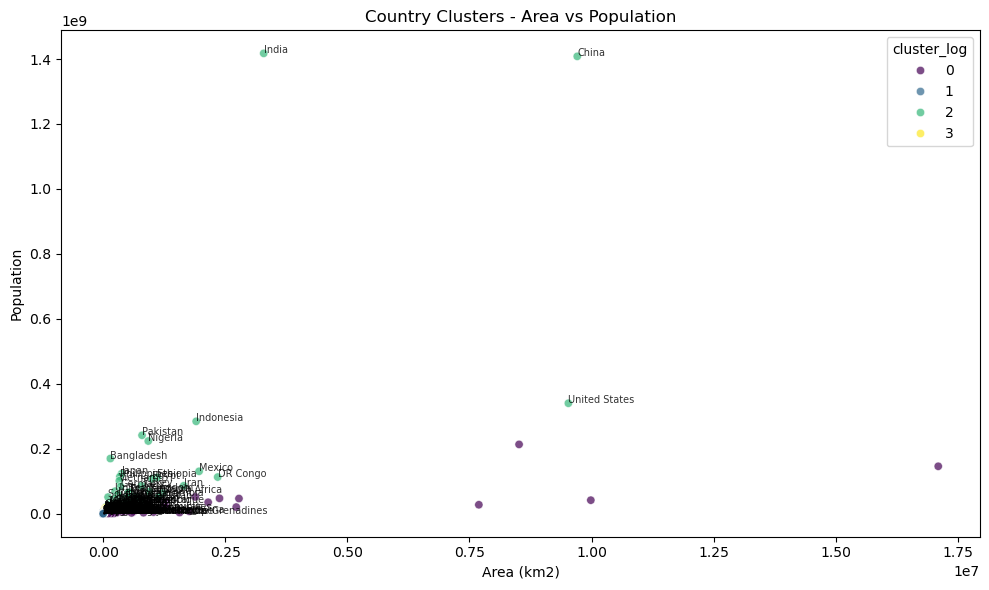

In [69]:
##visualising clusters

plt.figure(figsize=(10,6))
sns.scatterplot(data=df,
                x='area_km2',
                y='population',
                hue='cluster_log',
                palette='viridis',
                alpha=0.7)

for idx, row in df[df['cluster_log'] != 0].iterrows():
    plt.annotate(row['country'],
                 (row['area_km2'], row['population']),
                 fontsize=7,
                 alpha=0.8)
plt.title('Country Clusters - Area vs Population')
plt.xlabel('Area (km2)')
plt.ylabel('Population')
plt.tight_layout()
plt.show()